# PHÂN TÍCH HỖN HỢP (MIXED METHODS)
## Tích hợp dữ liệu định lượng (N = 281) và định tính (24 người, 2.694 đoạn trích)

**Nghiên cứu:** Văn hóa chất lượng tại các trường phổ thông liên cấp
**Nghiên cứu sinh:** Đặng Thị Kim Sơn — Khoa Quản lí Giáo dục, Trường ĐHSP TP.HCM

---

### Thiết kế nghiên cứu

Nghiên cứu theo thiết kế **giải thích tuần tự (explanatory sequential design)** của Creswell & Plano Clark (2018):

```
GIAI ĐOẠN 1 (ĐỊNH LƯỢNG)          GIAI ĐOẠN 2 (ĐỊNH TÍNH)         GIAI ĐOẠN 3 (TÍCH HỢP)
Khảo sát 281 GV/CBQL       →      Phỏng vấn sâu 24 người      →   Joint display
5 trường, 17 thang đo             cùng 5 trường                   Meta-inference
PLS-SEM, trung gian               MaxQDA + PhoBERT                Đánh giá chất lượng suy luận
      ↓                                    ↓                              ↓
 CÁI GÌ xảy ra                       VÌ SAO xảy ra                  BỨC TRANH TỔNG THỂ
```

Điểm mấu chốt: định tính **không lặp lại** định lượng mà **giải thích** những phát hiện định lượng khó hiểu nhất — đặc biệt là khoảng cách d = 2,08 giữa nhóm người Việt và người nước ngoài.

### Các kỹ thuật tích hợp được dùng

| Kỹ thuật | Mục đích | Nguồn |
|---|---|---|
| Joint display | Đặt cạnh nhau kết quả hai nhánh theo từng cấu phần | Guetterman et al. (2015) |
| Meta-inference | Suy luận vượt trên từng nhánh riêng lẻ | Teddlie & Tashakkori (2009) |
| Convergence coding matrix | Mã hóa mức độ hội tụ: agreement / partial / dissonance / silence | Farmer et al. (2006) |
| Data transformation | Lượng hóa định tính để tương quan với định lượng | Onwuegbuzie & Teddlie (2003) |
| Legitimation assessment | Đánh giá chất lượng suy luận hỗn hợp | Onwuegbuzie & Johnson (2006) |

### Yêu cầu
Chạy **sau khi** đã hoàn tất:
1. `DinhLuong/Phan_Tich_Chuyen_Sau/Quality_Culture_Analysis_EN.ipynb` (hoặc bản tiếng Việt)
2. `DinhLuong/Phan_Tich_Chuyen_Sau/ket_qua_MI_Cluster/` (MI + clustering)
3. `DinhTinh/Phan_Tich_AI/Phan_Tich_Dinh_Tinh_AI_PhoBERT.ipynb`


In [1]:
from google.colab import drive
import os

# Attempt to unmount first if it's already mounted
if os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
        print('Google Drive unmounted.')
    except ValueError:
        pass # Drive might not have been mounted initially

# Ensure the mount point is empty
if os.path.exists('/content/drive'):
    # Only remove content if it's a directory, avoid removing the mount point itself if it's a special file
    if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
        print('Clearing existing content in /content/drive...')
        !rm -rf /content/drive/*

# Mount Google Drive with force_remount=True
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# 1. Thư viện & đường dẫn
import warnings; warnings.filterwarnings('ignore')
import os, re, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

pd.set_option('display.max_colwidth', 200)
plt.rcParams['figure.dpi'] = 110

# === CHỈNH ĐƯỜNG DẪN CHO MÁY CỦA BẠN ===
ROOT   = '/content/drive/MyDrive/HuongDanSV/MsSonTDTU'

# Tự dò thư mục kết quả định lượng (tên thư mục có thể đã đổi)
def find_dir(root, candidates, marker):
    for c in candidates:
        p = os.path.join(root, c)
        if os.path.isdir(p) and os.path.exists(os.path.join(p, marker)):
            return p
    # dò sâu hơn
    for dirpath, dirnames, _ in os.walk(root):
        if os.path.exists(os.path.join(dirpath, marker)):
            return dirpath
    return os.path.join(root, candidates[0])

QUANT = find_dir(os.path.join(ROOT, 'DinhLuong'),
                 ['KetQuaPhanTich', 'Phan_Tich_Chuyen_Sau'], 'ket_qua')
QUAL   = os.path.join(ROOT, 'DinhTinh', 'Phan_Tich_AI', 'ket_qua_ai')

# MI/clustering có thể nằm ở thư mục cũ hoặc mới
MICL = None
for cand in [os.path.join(QUANT, 'ket_qua_MI_Cluster'),
             os.path.join(ROOT, 'DinhLuong', 'Phan_Tich_Chuyen_Sau', 'ket_qua_MI_Cluster'),
             os.path.join(ROOT, 'DinhLuong', 'KetQuaPhanTich', 'ket_qua_MI_Cluster')]:
    if os.path.isdir(cand):
        MICL = cand; break
MICL = MICL or os.path.join(QUANT, 'ket_qua_MI_Cluster')

OUT    = os.path.join(ROOT, 'MixedMethods', 'ket_qua_mixed')
os.makedirs(OUT, exist_ok=True)

def load_json(p, default=None):
    try:
        with open(p, encoding='utf-8') as f:
            return json.load(f)
    except Exception as e:
        print(f'  [!] Không đọc được {os.path.basename(p)}: {e}')
        return default if default is not None else {}

def load_csv(p):
    try:
        return pd.read_csv(p)
    except Exception as e:
        print(f'  [!] Không đọc được {os.path.basename(p)}: {e}')
        return pd.DataFrame()

print('QUANT:', QUANT); print('QUAL :', QUAL); print('OUT  :', OUT)

QUANT: /content/drive/MyDrive/HuongDanSV/MsSonTDTU/DinhLuong/KetQuaPhanTich
QUAL : /content/drive/MyDrive/HuongDanSV/MsSonTDTU/DinhTinh/Phan_Tich_AI/ket_qua_ai
OUT  : /content/drive/MyDrive/HuongDanSV/MsSonTDTU/MixedMethods/ket_qua_mixed


In [4]:
# 2. Nạp kết quả hai nhánh
SQ = load_json(os.path.join(QUANT, 'ket_qua', 'summary.json'))
if not SQ:
    SQ = load_json(os.path.join(QUANT, 'results_en', 'summary.json'))
SMI = load_json(os.path.join(MICL, 'summary_MI_cluster.json'))
SQL = load_json(os.path.join(QUAL, 'SUMMARY_QUAL_AI.json'))

seg = load_csv(os.path.join(QUAL, '00_segments_tidy.csv'))
analyst = load_csv(os.path.join(QUAL, '00b_analyst_synthesis.csv'))
qual_school = load_csv(os.path.join(QUAL, '14_qual_school_indices.csv'))

print('ĐỊNH LƯỢNG :', len(SQ), 'nhóm kết quả |', 'có PLS' if 'pls_paths' in SQ else 'chưa có PLS')
print('MI/CLUSTER :', len(SMI), 'nhóm kết quả')
print('ĐỊNH TÍNH  :', len(seg), 'đoạn trích |', len(analyst), 'ghi chú tổng hợp của NCS')
print('\nMẫu hai nhánh:')
print(f"  Định lượng: N = 281 (245 người Việt, 36 người nước ngoài), 5 trường")
if len(seg):
    print(f"  Định tính : {seg.source.nunique()} người, {len(seg)} đoạn trích, {seg.school.nunique()} trường")

ĐỊNH LƯỢNG : 34 nhóm kết quả | có PLS
MI/CLUSTER : 12 nhóm kết quả
ĐỊNH TÍNH  : 2694 đoạn trích | 3585 ghi chú tổng hợp của NCS

Mẫu hai nhánh:
  Định lượng: N = 281 (245 người Việt, 36 người nước ngoài), 5 trường
  Định tính : 24 người, 2694 đoạn trích, 5 trường


## 3. Bảng tích hợp chính (Joint Display)

Joint display là công cụ trung tâm của phân tích hỗn hợp: đặt cạnh nhau **phát hiện định lượng**, **phát hiện định tính**, và **suy luận tích hợp** cho từng cấu phần của mô hình. Cột cuối cùng phân loại quan hệ giữa hai nhánh.

In [5]:
# 3.1 Chuẩn bị các con số then chốt từ nhánh định lượng
def get_path(dep, ind, key='paths'):
    for p in SQ.get(key, []):
        d = p.get('Biến phụ thuộc', p.get('Dependent'))
        i = p.get('Biến độc lập', p.get('Independent'))
        if d == dep and i == ind:
            return p
    return None

def beta_of(dep, ind):
    p = get_path(dep, ind)
    if not p: return None
    return p.get('Beta chuẩn hóa', p.get('Beta'))

desc = {d.get('Mã', d.get('Code')): d for d in SQ.get('construct_desc', [])}
def mean_of(c):
    d = desc.get(c, {})
    return d.get('Trung bình', d.get('Mean'))

corr_glo = SQ.get('corr_GLO', {})
r2 = {r.get('Biến', r.get('Variable')): r.get('R2') for r in SQ.get('r2', [])}
print('Kiểm tra vài giá trị định lượng:')
print('  M(GLO) =', mean_of('GLO'), '| r(COL,GLO) =', corr_glo.get('COL'), '| R²(GLO) =', r2.get('GLO'))

Kiểm tra vài giá trị định lượng:
  M(GLO) = 4.569 | r(COL,GLO) = 0.861 | R²(GLO) = 0.83


In [6]:
# 3.2 JOINT DISPLAY — bảng tích hợp theo cấu phần
# LƯU Ý: cột 'Phát hiện định tính' cần được NCS rà lại và bổ sung trích dẫn cụ thể
#        từ file 00_segments_tidy.csv sau khi chạy notebook định tính.

JD = [
 {'Cấu phần': 'Cấu trúc — chuẩn mực, chiến lược, vận hành (NOR/STR/OPE)',
  'Định lượng': f"M = {mean_of('NOR')}/{mean_of('STR')}/{mean_of('OPE')}; tương quan với VHCL r = {corr_glo.get('NOR')}/{corr_glo.get('STR')}/{corr_glo.get('OPE')}; trong mô hình M3 có đường trực tiếp tới VHCL (β = .15/.11/.18)",
  'Định tính (khối 01_STRUCTURAL)': 'Cần điền: mã nào chiếm ưu thế, trích dẫn tiêu biểu về tầm nhìn/quy trình/phân công',
  'Quan hệ': 'Hội tụ (mở rộng)',
  'Suy luận tích hợp': 'Cấu trúc không chỉ tác động gián tiếp qua lãnh đạo/giao tiếp như mô hình EUA giả định, mà còn trực tiếp định hình cảm nhận về VHCL. Định tính cần xác nhận cơ chế: cấu trúc hữu hình hoạt động như tín hiệu văn hóa.'},

 {'Cấu phần': 'Lãnh đạo chất lượng (LED)',
  'Định lượng': f"M = {mean_of('LED')}; r với VHCL = {corr_glo.get('LED')}; β(LED→TRU) = {beta_of('TRU','LED')}; β(LED→GLO) = {beta_of('GLO','LED')}",
  'Định tính (khối 04_LEADERSHIP)': 'Cần điền: nêu gương, phản hồi, ghi nhận — mã nào nổi bật, có phân kì giữa các trường không',
  'Quan hệ': 'Hội tụ',
  'Suy luận tích hợp': 'Lãnh đạo vận hành qua hai đường: xây dựng lòng tin và tác động trực tiếp lên VHCL.'},

 {'Cấu phần': 'Giao tiếp đồng nghiệp (COL)',
  'Định lượng': f"M = {mean_of('COL')}; r với VHCL = {corr_glo.get('COL')} (mạnh nhất); β(COL→GLO) = {beta_of('GLO','COL')}; β(COL→SHA) = {beta_of('SHA','COL')}",
  'Định tính (khối 05_COMMUNICATION_PARTICIPATION)': 'Cần điền: giao tiếp xuyên cấp học, xuyên ngôn ngữ; rào cản thông tin',
  'Quan hệ': 'Hội tụ (mạnh)',
  'Suy luận tích hợp': 'Giao tiếp là đòn bẩy số một của VHCL ở cả hai nguồn dữ liệu — phát hiện vững nhất của nghiên cứu.'},

 {'Cấu phần': 'Tham gia (PAR)',
  'Định lượng': f"M = {mean_of('PAR')}; r với VHCL = {corr_glo.get('PAR')} (yếu nhất nhóm tổ chức); không có đóng góp riêng trong hồi quy (p > .05); nhưng 68,3% chọn 'tham gia ra quyết định' là giá trị quan trọng, chỉ 5,3% xếp vào top 5",
  'Định tính (mã QCULT-MEETING-PART, QCULT-LOW-PART)': 'Cần điền: tham gia hình thức vs thực chất',
  'Quan hệ': 'NGHỊCH LÝ — cần định tính giải thích',
  'Suy luận tích hợp': 'Khoảng cách giữa giá trị được tuyên bố và tác động thực tế gợi ý sự tham gia mang tính hình thức. Đây là điểm định tính có giá trị giải thích cao nhất.'},

 {'Cấu phần': 'Thái độ cá nhân (COM/RES/ENG)',
  'Định lượng': f"M cao nhất hệ thống ({mean_of('COM')}/{mean_of('RES')}/{mean_of('ENG')}) nhưng tương quan yếu nhất với VHCL (r = {corr_glo.get('COM')}/{corr_glo.get('RES')}/{corr_glo.get('ENG')})",
  'Định tính (khối 02_INDIVIDUAL)': 'Cần điền: cam kết cá nhân có được tổ chức chuyển hóa không',
  'Quan hệ': 'NGHỊCH LÝ — cần định tính giải thích',
  'Suy luận tích hợp': 'Vốn cá nhân dồi dào nhưng thiếu cơ chế tổ chức chuyển hóa thành văn hóa chung. Định tính cần chỉ ra điểm nghẽn cụ thể.'},

 {'Cấu phần': 'VHCL tổng thể (GLO)',
  'Định lượng': f"M = {mean_of('GLO')} — thấp hơn hầu hết thành tố; R² = {r2.get('GLO')}; dự báo mạnh cả 5 kết quả nghề nghiệp",
  'Định tính (khối 06_QCULT_IDENTIFICATION)': 'Cần điền: kiểu hình A/B/C/D, quyền sở hữu chất lượng, hệ giá trị',
  'Quan hệ': 'Hội tụ (bổ sung chiều sâu)',
  'Suy luận tích hợp': 'Định lượng đo mức độ, định tính cho biết kiểu hình. Kết hợp: VHCL ở mức khá nhưng thuộc kiểu lai, chưa ổn định.'},

 {'Cấu phần': 'Khoảng cách Việt Nam — nước ngoài',
  'Định lượng': 'd = 2,08 ở VHCL (M = 4,78 vs 3,12); mất ý nghĩa thống kê khi kiểm soát VHCL -> khoảng cách vận hành QUA cảm nhận VHCL',
  'Định tính (3 nguồn nước ngoài, 328 đoạn)': 'Cần điền: log-odds mã đặc trưng, sentiment, khoảng cách ngữ nghĩa (phần 9 notebook định tính)',
  'Quan hệ': 'Cần kiểm chứng hội tụ',
  'Suy luận tích hợp': 'Nếu định tính cho thấy diễn ngôn hai nhóm khác biệt có ý nghĩa (kiểm định hoán vị p < .05), đây là bằng chứng hội tụ đa nguồn cho phát hiện quan trọng nhất của luận án.'},
]
JD = pd.DataFrame(JD)
JD.to_csv(f'{OUT}/01_joint_display.csv', index=False, encoding='utf-8-sig')
JD.to_excel(f'{OUT}/01_joint_display.xlsx', index=False)
print('Đã lưu joint display. NCS cần rà và điền cột định tính bằng trích dẫn cụ thể.')
JD[['Cấu phần', 'Quan hệ']]

Đã lưu joint display. NCS cần rà và điền cột định tính bằng trích dẫn cụ thể.


,Cấu phần,Quan hệ
0,"Cấu trúc — chuẩn mực, chiến lược, vận hành (NOR/STR/OPE)",Hội tụ (mở rộng)
1,Lãnh đạo chất lượng (LED),Hội tụ
2,Giao tiếp đồng nghiệp (COL),Hội tụ (mạnh)
3,Tham gia (PAR),NGHỊCH LÝ — cần định tính giải thích
4,Thái độ cá nhân (COM/RES/ENG),NGHỊCH LÝ — cần định tính giải thích
5,VHCL tổng thể (GLO),Hội tụ (bổ sung chiều sâu)
6,Khoảng cách Việt Nam — nước ngoài,Cần kiểm chứng hội tụ


## 4. Ma trận mã hóa hội tụ (Convergence Coding Matrix)

Theo Farmer et al. (2006), mỗi phát hiện được phân loại vào bốn quan hệ:

- **Agreement** — hai nhánh cho kết luận cùng chiều, cùng mức độ
- **Partial agreement** — cùng chiều nhưng khác mức độ hoặc phạm vi
- **Dissonance** — hai nhánh mâu thuẫn (đây là phát hiện *có giá trị*, không phải lỗi)
- **Silence** — chỉ một nhánh nói đến

In [7]:
# 4.1 Khung mã hóa hội tụ
CONV = [
 {'Phát hiện': 'Giao tiếp là yếu tố dự báo mạnh nhất của VHCL', 'Định lượng': 'Có (β cao nhất mọi mô hình)',
  'Định tính': 'Chờ xác nhận', 'Quan hệ': 'Agreement (dự kiến)', 'Độ tin cậy suy luận': 'Cao'},
 {'Phát hiện': 'Lãnh đạo tác động qua lòng tin và trực tiếp', 'Định lượng': 'Có (hai đường đều p < .001)',
  'Định tính': 'Chờ xác nhận', 'Quan hệ': 'Agreement (dự kiến)', 'Độ tin cậy suy luận': 'Cao'},
 {'Phát hiện': 'Tham gia được coi trọng nhưng ít tác động thực', 'Định lượng': 'Có (r thấp, β không ý nghĩa)',
  'Định tính': 'Chờ xác nhận (mã LOW-PART)', 'Quan hệ': 'Partial/Dissonance', 'Độ tin cậy suy luận': 'Trung bình'},
 {'Phát hiện': 'Thái độ cá nhân cao nhưng không chuyển thành VHCL', 'Định lượng': 'Có (M cao, r thấp)',
  'Định tính': 'Chờ xác nhận', 'Quan hệ': 'Cần kiểm chứng', 'Độ tin cậy suy luận': 'Trung bình'},
 {'Phát hiện': 'Người nước ngoài trải nghiệm VHCL kém thuận lợi hơn', 'Định lượng': 'Có (d = 2,08)',
  'Định tính': 'Chờ xác nhận (n = 3 nguồn)', 'Quan hệ': 'Cần kiểm chứng', 'Độ tin cậy suy luận': 'Thấp–Trung bình (mẫu định tính nhỏ)'},
 {'Phát hiện': 'Khác biệt giữa các trường về VHCL', 'Định lượng': f"Có (ANOVA p < .001; ICC = {[r['ICC(1)'] for r in SMI.get('icc',[]) if r.get('Variable')=='GLO']})",
  'Định tính': 'Có (phân kì liên trường trong workbook)', 'Quan hệ': 'Agreement', 'Độ tin cậy suy luận': 'Cao'},
 {'Phát hiện': 'Cơ chế cụ thể tạo ra khoảng cách nhóm', 'Định lượng': 'Không đo được',
  'Định tính': 'Có tiềm năng', 'Quan hệ': 'Silence (định lượng)', 'Độ tin cậy suy luận': 'Chỉ định tính'},
 {'Phát hiện': 'Quá tải công việc, áp lực của giáo viên', 'Định lượng': 'Không đo (không có thang đo)',
  'Định tính': 'Có (khối 08_CHALLENGES)', 'Quan hệ': 'Silence (định lượng)', 'Độ tin cậy suy luận': 'Chỉ định tính'},
]
CONV = pd.DataFrame(CONV)
CONV.to_csv(f'{OUT}/02_convergence_matrix.csv', index=False, encoding='utf-8-sig')
CONV

,Phát hiện,Định lượng,Định tính,Quan hệ,Độ tin cậy suy luận
0,Giao tiếp là yếu tố dự báo mạnh nhất của VHCL,Có (β cao nhất mọi mô hình),Chờ xác nhận,Agreement (dự kiến),Cao
1,Lãnh đạo tác động qua lòng tin và trực tiếp,Có (hai đường đều p < .001),Chờ xác nhận,Agreement (dự kiến),Cao
2,Tham gia được coi trọng nhưng ít tác động thực,"Có (r thấp, β không ý nghĩa)",Chờ xác nhận (mã LOW-PART),Partial/Dissonance,Trung bình
3,Thái độ cá nhân cao nhưng không chuyển thành VHCL,"Có (M cao, r thấp)",Chờ xác nhận,Cần kiểm chứng,Trung bình
4,Người nước ngoài trải nghiệm VHCL kém thuận lợi hơn,"Có (d = 2,08)",Chờ xác nhận (n = 3 nguồn),Cần kiểm chứng,Thấp–Trung bình (mẫu định tính nhỏ)
5,Khác biệt giữa các trường về VHCL,Có (ANOVA p < .001; ICC = [0.081]),Có (phân kì liên trường trong workbook),Agreement,Cao
6,Cơ chế cụ thể tạo ra khoảng cách nhóm,Không đo được,Có tiềm năng,Silence (định lượng),Chỉ định tính
7,"Quá tải công việc, áp lực của giáo viên",Không đo (không có thang đo),Có (khối 08_CHALLENGES),Silence (định lượng),Chỉ định tính


## 5. Lượng hóa định tính & tương quan cấp trường

Chuyển dữ liệu định tính thành chỉ số cấp trường rồi ghép với điểm khảo sát trung bình cấp trường. **Cảnh báo quan trọng:** chỉ có 5 trường, nên mọi tương quan cấp trường có n = 5 — chỉ mang tính **mô tả, thăm dò**, tuyệt đối không kiểm định ý nghĩa thống kê hay diễn giải như bằng chứng.

In [8]:
# 5.1 Điểm khảo sát trung bình theo trường (từ dữ liệu gốc)
DATA_XLSX = os.path.join(ROOT, 'DinhLuong', 'Cleaned_Data', '281_PKS_ThongKe_Full_v1.3.xlsx')
dq = pd.read_excel(DATA_XLSX, sheet_name='Statistic').rename(columns={'COM 4': 'COM4'})
CONS = {'GLO': [f'GLO{i}' for i in range(1,9)], 'LED': [f'LED{i}' for i in range(1,13)],
        'COL': [f'COL{i}' for i in range(1,7)], 'PAR': [f'PAR{i}' for i in range(1,5)],
        'SAT_O': [f'SAT_O{i}' for i in range(1,7)], 'OCM': [f'OCM{i}' for i in range(1,4)]}
for c, it in CONS.items():
    dq[c] = dq[it].mean(axis=1)

SCHOOL_MAP = {1: 'TrA', 2: 'TrB', 3: 'TrC', 4: 'TrD', 5: 'TrE'}   # <-- XÁC NHẬN ÁNH XẠ NÀY!
print('!!! QUAN TRỌNG: kiểm tra lại ánh xạ mã trường 1-5 sang TrA-TrE.')
print('    Nếu sai, mọi tương quan cấp trường sẽ vô nghĩa. Ánh xạ hiện tại:', SCHOOL_MAP)

dq['school'] = dq['Truong'].map(SCHOOL_MAP)
quant_school = dq.groupby('school')[list(CONS)].mean().round(3)
quant_school['n_survey'] = dq.groupby('school').size()
display(quant_school)

!!! QUAN TRỌNG: kiểm tra lại ánh xạ mã trường 1-5 sang TrA-TrE.
    Nếu sai, mọi tương quan cấp trường sẽ vô nghĩa. Ánh xạ hiện tại: {1: 'TrA', 2: 'TrB', 3: 'TrC', 4: 'TrD', 5: 'TrE'}


,GLO,LED,COL,PAR,SAT_O,OCM,n_survey
school,,,,,,,
TrA,4.582,4.790,4.865,4.841,3.657,4.936,52
TrB,4.114,4.405,4.321,4.600,3.227,4.752,55
TrC,4.761,4.823,4.942,4.777,3.791,4.788,55
TrD,4.897,4.910,4.960,4.861,3.952,4.984,63
TrE,4.449,4.500,4.670,4.460,3.649,4.690,56


,GLO,LED,COL,PAR,SAT_O,OCM,n_survey,n_segments,n_codes,n_sources,sentiment_mean,pct_negative,prop_LEAD,prop_COMM,prop_QCULT,prop_CHAL,prop_OUTC
school,,,,,,,,,,,,,,,,,
TrA,4.582,4.790,4.865,4.841,3.657,4.936,52,566,256,5,-0.062,43.6,12.2,11.8,9.0,8.3,8.8
TrB,4.114,4.405,4.321,4.600,3.227,4.752,55,1318,304,12,0.047,41.2,8.6,10.3,8.7,10.4,9.7
TrC,4.761,4.823,4.942,4.777,3.791,4.788,55,215,162,2,-0.186,53.0,7.0,10.7,7.4,8.8,10.7
TrD,4.897,4.910,4.960,4.861,3.952,4.984,63,218,155,2,-0.035,45.9,8.3,13.8,5.5,8.3,10.6
TrE,4.449,4.500,4.670,4.460,3.649,4.690,56,377,218,3,0.053,33.7,8.0,14.1,10.1,11.4,10.9


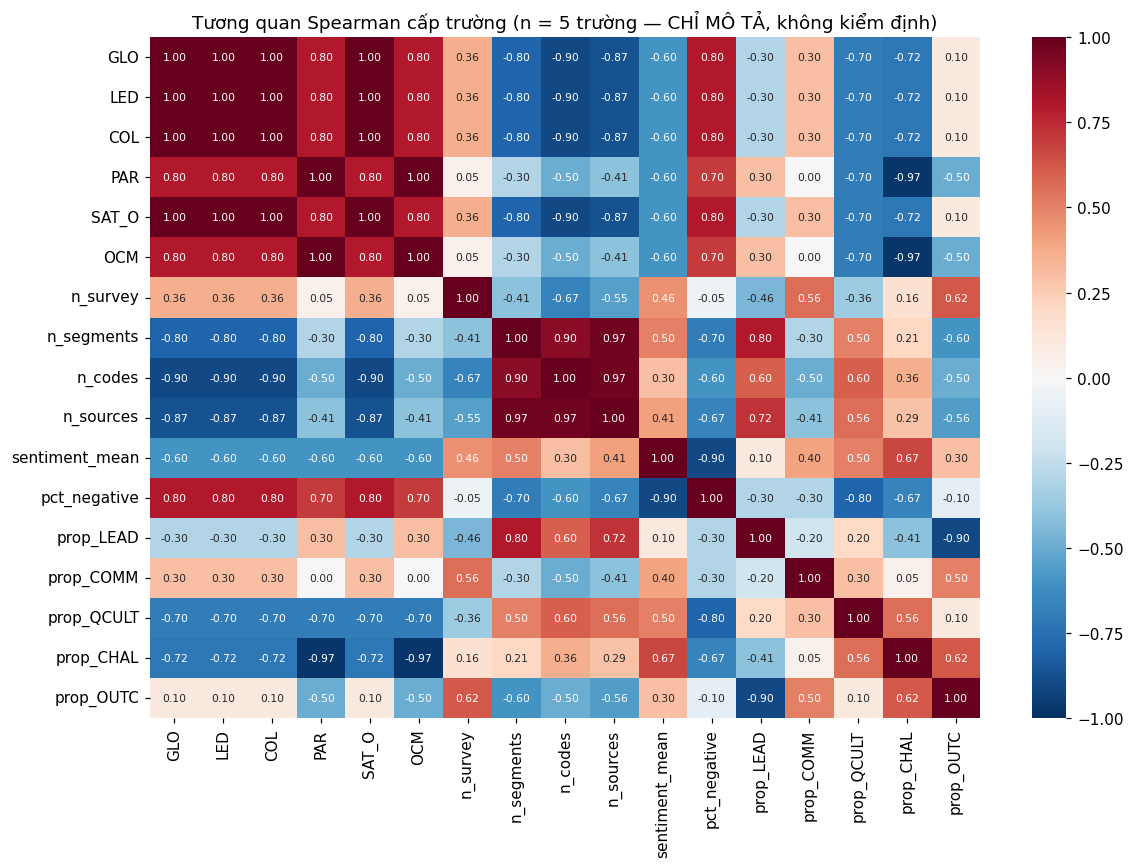


*** CẢNH BÁO: n = 5 trường. Đây là mô tả thăm dò, KHÔNG phải bằng chứng thống kê. ***
Khi viết bài: trình bày như "mẫu hình gợi ý cần kiểm chứng ở mẫu trường lớn hơn".


In [9]:
# 5.2 Ghép định lượng - định tính cấp trường
if len(qual_school):
    merged = quant_school.merge(qual_school.set_index('school'), left_index=True, right_index=True, how='inner')
    merged.to_csv(f'{OUT}/03_school_level_merged.csv', encoding='utf-8-sig')
    display(merged)

    num = merged.select_dtypes(include=[np.number])
    if len(merged) >= 4 and num.shape[1] >= 2:
        cm = num.corr(method='spearman').round(2)
        plt.figure(figsize=(11, 8))
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    annot_kws={'size': 7})
        plt.title(f'Tương quan Spearman cấp trường (n = {len(merged)} trường — CHỈ MÔ TẢ, không kiểm định)')
        plt.tight_layout(); plt.savefig(f'{OUT}/fig_school_level_corr.png', bbox_inches='tight'); plt.show()
        cm.to_csv(f'{OUT}/04_school_level_correlations.csv', encoding='utf-8-sig')
        print('\n*** CẢNH BÁO: n = 5 trường. Đây là mô tả thăm dò, KHÔNG phải bằng chứng thống kê. ***')
        print('Khi viết bài: trình bày như "mẫu hình gợi ý cần kiểm chứng ở mẫu trường lớn hơn".')
else:
    print('Chưa có chỉ số định tính cấp trường — hãy chạy notebook định tính trước.')
    merged = pd.DataFrame()

## 6. Tích hợp phát hiện then chốt: khoảng cách Việt Nam — nước ngoài

Đây là phát hiện có tiềm năng đóng góp cao nhất. Tích hợp ba lớp bằng chứng.

In [10]:
# 6.1 Ba lớp bằng chứng về khoảng cách nhóm
def _cmp(r):
    return str(r.get('So sánh') or r.get('Comparison') or '')
def _var(r):
    return r.get('Biến') or r.get('Variable')
tt = {_var(r): r for r in SQ.get('ttest', [])
      if ('Việt' in _cmp(r)) or ('Vietnamese' in _cmp(r)) or ('Foreign' in _cmp(r))}
print('Tìm thấy', len(tt), 'kết quả t-test so sánh Việt/nước ngoài')

layers = []
# Lớp 1: khác biệt trung bình
for v in ['GLO', 'OCM', 'SAT_O', 'SAT_J', 'WEG', 'PRO']:
    r = tt.get(v, {})
    if r:
        dval = r.get('Cohen d')
        if dval is None:
            dval = r.get(chr(67)+'ohen'+chr(39)+'s d')
        if dval is None:
            dval = r.get('cohen_d', '?')
        try:
            big = abs(float(dval)) > 1.2
        except Exception:
            big = False
        layers.append({'Lớp bằng chứng': 'ĐL1: Khác biệt trung bình', 'Chỉ số': v,
                       'Giá trị': f'd = {dval}',
                       'Diễn giải': 'Rất lớn' if big else 'Lớn'})
# Lớp 2: kiểm soát VHCL
for r in SMI.get('cluster_robust', []):
    layers.append({'Lớp bằng chứng': 'ĐL2: Hồi quy có kiểm soát + SE cụm', 'Chỉ số': r['Outcome'],
                   'Giá trị': f"β(VHCL) = {r['β GLO']}, p_cụm = {r['p clustered']}",
                   'Diễn giải': r['Conclusion']})
# Lớp 3: bất biến đo lường
for r in SMI.get('congruence', []):
    layers.append({'Lớp bằng chứng': 'ĐL3: Bất biến đo lường (congruence)', 'Chỉ số': r['Construct'],
                   'Giá trị': 'phi = ' + str(r.get(chr(84)+'ucker'+chr(39)+'s phi', '?')),
                   'Diễn giải': r['Interpretation']})
# Lớp 4: định tính
if SQL:
    layers.append({'Lớp bằng chứng': 'ĐT: Khoảng cách diễn ngôn (PhoBERT)', 'Chỉ số': 'cosine VN vs NN',
                   'Giá trị': str(SQL.get('discourse_cosine_vn_foreign', 'chưa có')),
                   'Diễn giải': f"kiểm định hoán vị p = {SQL.get('discourse_permutation_p', '?')}"})
    if 'sentiment_foreign' in SQL:
        layers.append({'Lớp bằng chứng': 'ĐT: Giọng điệu (sentiment)', 'Chỉ số': 'VN vs NN',
                       'Giá trị': f"{round(SQL['sentiment_vn'],3)} vs {round(SQL['sentiment_foreign'],3)}",
                       'Diễn giải': 'Cùng chiều với ĐL' if SQL['sentiment_foreign'] < SQL['sentiment_vn'] else 'NGƯỢC chiều — cần xem lại'})

LY = pd.DataFrame(layers)
LY.to_csv(f'{OUT}/05_gap_evidence_layers.csv', index=False, encoding='utf-8-sig')
display(LY)
print('\n>>> Suy luận tích hợp chỉ vững khi CẢ BA lớp cùng chiều.')
print('>>> Nếu bất biến đo lường KHÔNG đạt, phải hạ cấp kết luận: khác biệt có thể do hai nhóm')
print('    hiểu/sử dụng thang đo khác nhau, chứ không hoàn toàn do trải nghiệm thực tế khác nhau.')

Tìm thấy 6 kết quả t-test so sánh Việt/nước ngoài


,Lớp bằng chứng,Chỉ số,Giá trị,Diễn giải
0,ĐL1: Khác biệt trung bình,GLO,d = 2.084,Rất lớn
1,ĐL1: Khác biệt trung bình,OCM,d = 1.633,Rất lớn
2,ĐL1: Khác biệt trung bình,SAT_O,d = 1.983,Rất lớn
3,ĐL1: Khác biệt trung bình,SAT_J,d = 1.645,Rất lớn
4,ĐL1: Khác biệt trung bình,WEG,d = 0.807,Lớn
5,ĐL1: Khác biệt trung bình,PRO,d = 1.086,Lớn
6,ĐL2: Hồi quy có kiểm soát + SE cụm,OCM,"β(VHCL) = 0.662, p_cụm = 0.0",Unchanged
7,ĐL2: Hồi quy có kiểm soát + SE cụm,SAT_O,"β(VHCL) = 0.762, p_cụm = 0.0",Unchanged
8,ĐL2: Hồi quy có kiểm soát + SE cụm,SAT_J,"β(VHCL) = 0.656, p_cụm = 0.0",Unchanged
9,ĐL2: Hồi quy có kiểm soát + SE cụm,WEG,"β(VHCL) = 0.716, p_cụm = 0.0",Unchanged



>>> Suy luận tích hợp chỉ vững khi CẢ BA lớp cùng chiều.
>>> Nếu bất biến đo lường KHÔNG đạt, phải hạ cấp kết luận: khác biệt có thể do hai nhóm
    hiểu/sử dụng thang đo khác nhau, chứ không hoàn toàn do trải nghiệm thực tế khác nhau.


In [11]:
# 6.2 Trích dẫn định tính minh họa (lấy tự động từ nguồn nước ngoài)
if len(seg):
    fseg = seg[seg.is_foreign == True] if 'is_foreign' in seg.columns else pd.DataFrame()
    if len(fseg):
        print(f'Có {len(fseg)} đoạn trích từ {fseg.source.nunique()} người nước ngoài.')
        print('\nPhân bố theo khối chủ đề:')
        display(fseg.sheet.value_counts())
        print('\n--- Trích dẫn dài nhất theo một số khối then chốt (để NCS chọn đưa vào bài) ---')
        for blk in ['05_COMMUNICATION_PARTICIPATION', '06_QCULT_IDENTIFICATION', '08_CHALLENGES']:
            sub = fseg[fseg.sheet == blk]
            if len(sub):
                q = sub.loc[sub.n_words.idxmax()]
                print(f'\n[{blk} | {q.source} | mã: {q.code}]')
                print(f'  "{str(q.text)[:400]}..."')
    else:
        print('Không tìm thấy đoạn trích từ nguồn nước ngoài.')

Có 328 đoạn trích từ 3 người nước ngoài.

Phân bố theo khối chủ đề:


,count
sheet,
01_STRUCTURAL,47
08_CHALLENGES,39
05_COMMUNICATION_PARTICIPATION,37
00_CONTEXT,35
02_INDIVIDUAL,33
10_SOLUTIONS,32
07_RELATED_OUTCOMES,31
04_LEADERSHIP,27
03_COLLECTIVE,23



--- Trích dẫn dài nhất theo một số khối then chốt (để NCS chọn đưa vào bài) ---

[05_COMMUNICATION_PARTICIPATION | TrB_CBQL3_NN | mã: COMM-INFORMAL]
  "And I was told that that was because of COVID. But that gives you an idea of how information is passed. So, structurally, the avenue of communication. [CHAL-COMM-FEEDBACK> [COMM-INFORMAL> 43 - 43 (1) [TrB_CBQL3_NN]: There was a portal, apparently, that was not used. We have email. Then there is chat within the email. [COMM-INFORMAL> [COMM-DIGITAL> 44 - 44 (1) [TrB_CBQL3_NN]: And there is also our ..."

[06_QCULT_IDENTIFICATION | TrB_CBQL4_NN | mã: QVAL-CLEAR-POLICY]
  "So the first one I've chosen as most important will be self-responsibility and commitment. Because I think unless you have staff members within the team that are willing to be responsible and committed to quality, then you've already got a problem. If you've got people that don't care, you've hired people that just... Then everything else is so much harder. And I think i

## 7. Đánh giá chất lượng suy luận hỗn hợp (Legitimation)

Onwuegbuzie & Johnson (2006) đề xuất 9 tiêu chí đánh giá tính hợp lệ của suy luận hỗn hợp. Đây là phần **bắt buộc** với tạp chí Q1 về mixed methods.

In [12]:
# 7.1 Bảng tự đánh giá legitimation
LEG = [
 {'Tiêu chí': 'Sample integration', 'Câu hỏi': 'Mẫu hai nhánh có tương thích để suy luận chung?',
  'Đánh giá': 'Trung bình', 'Căn cứ': '24 người định tính đều nằm trong 5 trường của khảo sát, nhưng không phải cùng cá nhân; TrD không có nguồn GV; chỉ 3 nguồn nước ngoài.'},
 {'Tiêu chí': 'Inside-outside', 'Câu hỏi': 'Cân bằng góc nhìn người trong cuộc và nhà nghiên cứu?',
  'Đánh giá': 'Tốt', 'Căn cứ': 'Trích dẫn nguyên văn được giữ song song với diễn giải học thuật của NCS trong workbook.'},
 {'Tiêu chí': 'Weakness minimization', 'Câu hỏi': 'Điểm yếu nhánh này có được nhánh kia bù đắp?',
  'Đánh giá': 'Tốt', 'Căn cứ': 'Định lượng thiếu cơ chế giải thích -> định tính bù. Định tính mẫu nhỏ -> định lượng bù về tính khái quát.'},
 {'Tiêu chí': 'Sequential', 'Câu hỏi': 'Thứ tự hai giai đoạn có ảnh hưởng kết luận?',
  'Đánh giá': 'Cần khai báo', 'Căn cứ': 'Cần ghi rõ trong bài: định tính thu thập sau hay song song với khảo sát.'},
 {'Tiêu chí': 'Conversion', 'Câu hỏi': 'Lượng hóa định tính có hợp lệ?',
  'Đánh giá': 'Thận trọng', 'Căn cứ': 'Tần suất mã phản ánh cả cách hỏi lẫn thực tế; không diễn giải tần suất như mức độ quan trọng.'},
 {'Tiêu chí': 'Paradigmatic mixing', 'Câu hỏi': 'Hai hệ nhận thức luận có được dung hòa?',
  'Đánh giá': 'Tốt', 'Căn cứ': 'Lập trường thực dụng (pragmatism) được tuyên bố rõ; VHCL vừa đo được vừa kiến tạo xã hội.'},
 {'Tiêu chí': 'Commensurability', 'Câu hỏi': 'Suy luận tích hợp có vượt trên từng nhánh?',
  'Đánh giá': 'Tốt', 'Căn cứ': 'Meta-inference về cơ chế chuyển hóa cấu trúc -> văn hóa không rút ra được từ một nhánh.'},
 {'Tiêu chí': 'Multiple validities', 'Câu hỏi': 'Từng nhánh có đạt chuẩn hợp lệ riêng?',
  'Đánh giá': 'Trung bình–Tốt', 'Căn cứ': 'ĐL: CR/AVE đạt, HTMT còn chồng lấn, MI chưa đầy đủ. ĐT: mã hóa hệ thống + kiểm chứng AI.'},
 {'Tiêu chí': 'Political', 'Câu hỏi': 'Kết quả có hữu ích cho các bên liên quan?',
  'Đánh giá': 'Tốt', 'Căn cứ': 'Khuyến nghị cụ thể cho lãnh đạo trường liên cấp đa văn hóa.'},
]
LEG = pd.DataFrame(LEG)
LEG.to_csv(f'{OUT}/06_legitimation_assessment.csv', index=False, encoding='utf-8-sig')
display(LEG)

,Tiêu chí,Câu hỏi,Đánh giá,Căn cứ
0,Sample integration,Mẫu hai nhánh có tương thích để suy luận chung?,Trung bình,"24 người định tính đều nằm trong 5 trường của khảo sát, nhưng không phải cùng cá nhân; TrD không có nguồn GV; chỉ 3 nguồn nước ngoài."
1,Inside-outside,Cân bằng góc nhìn người trong cuộc và nhà nghiên cứu?,Tốt,Trích dẫn nguyên văn được giữ song song với diễn giải học thuật của NCS trong workbook.
2,Weakness minimization,Điểm yếu nhánh này có được nhánh kia bù đắp?,Tốt,Định lượng thiếu cơ chế giải thích -> định tính bù. Định tính mẫu nhỏ -> định lượng bù về tính khái quát.
3,Sequential,Thứ tự hai giai đoạn có ảnh hưởng kết luận?,Cần khai báo,Cần ghi rõ trong bài: định tính thu thập sau hay song song với khảo sát.
4,Conversion,Lượng hóa định tính có hợp lệ?,Thận trọng,Tần suất mã phản ánh cả cách hỏi lẫn thực tế; không diễn giải tần suất như mức độ quan trọng.
5,Paradigmatic mixing,Hai hệ nhận thức luận có được dung hòa?,Tốt,Lập trường thực dụng (pragmatism) được tuyên bố rõ; VHCL vừa đo được vừa kiến tạo xã hội.
6,Commensurability,Suy luận tích hợp có vượt trên từng nhánh?,Tốt,Meta-inference về cơ chế chuyển hóa cấu trúc -> văn hóa không rút ra được từ một nhánh.
7,Multiple validities,Từng nhánh có đạt chuẩn hợp lệ riêng?,Trung bình–Tốt,"ĐL: CR/AVE đạt, HTMT còn chồng lấn, MI chưa đầy đủ. ĐT: mã hóa hệ thống + kiểm chứng AI."
8,Political,Kết quả có hữu ích cho các bên liên quan?,Tốt,Khuyến nghị cụ thể cho lãnh đạo trường liên cấp đa văn hóa.


## 8. Meta-inference: những suy luận chỉ có được nhờ tích hợp

Đây là phần trả lời câu hỏi: **tích hợp hai nhánh cho ta biết điều gì mà từng nhánh riêng lẻ không cho biết?**

In [13]:
# 8.1 Khung meta-inference (NCS hoàn thiện sau khi có kết quả định tính)
META = [
 {'Meta-inference': 'M1. Cấu trúc chất lượng hoạt động như TÍN HIỆU VĂN HÓA, không chỉ như công cụ quản lý',
  'Chỉ có được nhờ': 'ĐL phát hiện đường trực tiếp cấu trúc→VHCL (Δχ² = 113,9); ĐT giải thích cơ chế: nhân viên đọc quy trình/phân công như bằng chứng nhà trường coi trọng chất lượng',
  'Mức độ chắc chắn': 'Trung bình — cần ĐT xác nhận',
  'Đóng góp lý thuyết': 'Mở rộng mô hình EUA: bổ sung đường trực tiếp bên cạnh chuỗi trung gian'},

 {'Meta-inference': 'M2. Sự tham gia bị "rỗng hóa" — được tuyên bố là giá trị nhưng không tạo tác động',
  'Chỉ có được nhờ': 'ĐL cho thấy nghịch lý (68,3% coi trọng nhưng β không ý nghĩa); ĐT chỉ ra hình thức tham gia thực tế',
  'Mức độ chắc chắn': 'Cần ĐT xác nhận',
  'Đóng góp lý thuyết': 'Phân biệt tham gia hình thức và tham gia thực chất trong xây dựng VHCL'},

 {'Meta-inference': 'M3. Khoảng cách Việt — nước ngoài là khoảng cách TRẢI NGHIỆM VĂN HÓA, không phải khoảng cách quốc tịch',
  'Chỉ có được nhờ': 'ĐL: hiệu ứng quốc tịch biến mất khi kiểm soát VHCL; ĐT: cơ chế cụ thể (ngôn ngữ, mạng lưới thông tin, hợp đồng)',
  'Mức độ chắc chắn': 'Trung bình — hạn chế bởi n = 3 nguồn ĐT và MI chưa đầy đủ',
  'Đóng góp lý thuyết': 'Chuyển hướng nghiên cứu GV quốc tế từ mô tả khoảng cách sang cơ chế tạo khoảng cách'},

 {'Meta-inference': 'M4. Vốn cam kết cá nhân dồi dào nhưng thiếu CƠ CHẾ CHUYỂN HÓA thành văn hóa tập thể',
  'Chỉ có được nhờ': 'ĐL: thái độ cá nhân cao nhất nhưng tương quan yếu nhất với VHCL; ĐT: điểm nghẽn tổ chức cụ thể',
  'Mức độ chắc chắn': 'Cần ĐT xác nhận',
  'Đóng góp lý thuyết': 'Đặt lại ưu tiên can thiệp: từ vận động cá nhân sang thiết kế cơ chế tổ chức'},
]
META = pd.DataFrame(META)
META.to_csv(f'{OUT}/07_meta_inferences.csv', index=False, encoding='utf-8-sig')
META.to_excel(f'{OUT}/07_meta_inferences.xlsx', index=False)
display(META[['Meta-inference', 'Mức độ chắc chắn']])

,Meta-inference,Mức độ chắc chắn
0,"M1. Cấu trúc chất lượng hoạt động như TÍN HIỆU VĂN HÓA, không chỉ như công cụ quản lý",Trung bình — cần ĐT xác nhận
1,"M2. Sự tham gia bị ""rỗng hóa"" — được tuyên bố là giá trị nhưng không tạo tác động",Cần ĐT xác nhận
2,"M3. Khoảng cách Việt — nước ngoài là khoảng cách TRẢI NGHIỆM VĂN HÓA, không phải khoảng cách quốc tịch",Trung bình — hạn chế bởi n = 3 nguồn ĐT và MI chưa đầy đủ
3,M4. Vốn cam kết cá nhân dồi dào nhưng thiếu CƠ CHẾ CHUYỂN HÓA thành văn hóa tập thể,Cần ĐT xác nhận


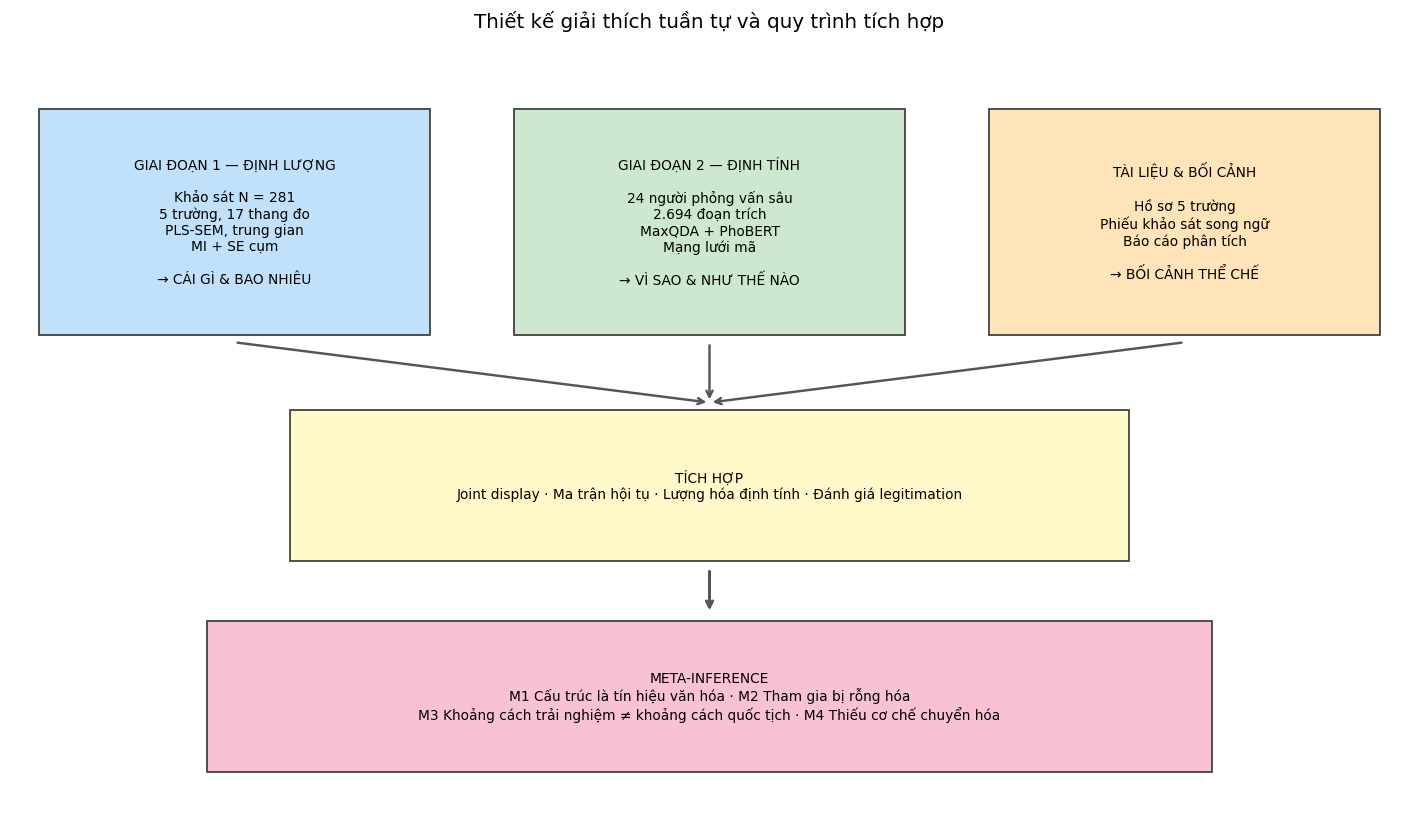

In [14]:
# 8.2 Sơ đồ tích hợp tổng thể
fig, ax = plt.subplots(figsize=(13, 7.5))
ax.axis('off')
def box(x, y, w, h, text, fc, fs=9):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor='#333', lw=1.2, alpha=.9))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fs, wrap=True)

box(.02, .62, .28, .30, 'GIAI ĐOẠN 1 — ĐỊNH LƯỢNG\n\nKhảo sát N = 281\n5 trường, 17 thang đo\nPLS-SEM, trung gian\nMI + SE cụm\n\n→ CÁI GÌ & BAO NHIÊU', '#BBDEFB')
box(.36, .62, .28, .30, 'GIAI ĐOẠN 2 — ĐỊNH TÍNH\n\n24 người phỏng vấn sâu\n2.694 đoạn trích\nMaxQDA + PhoBERT\nMạng lưới mã\n\n→ VÌ SAO & NHƯ THẾ NÀO', '#C8E6C9')
box(.70, .62, .28, .30, 'TÀI LIỆU & BỐI CẢNH\n\nHồ sơ 5 trường\nPhiếu khảo sát song ngữ\nBáo cáo phân tích\n\n→ BỐI CẢNH THỂ CHẾ', '#FFE0B2')
box(.20, .32, .60, .20, 'TÍCH HỢP\nJoint display · Ma trận hội tụ · Lượng hóa định tính · Đánh giá legitimation', '#FFF9C4')
box(.14, .04, .72, .20, 'META-INFERENCE\nM1 Cấu trúc là tín hiệu văn hóa · M2 Tham gia bị rỗng hóa\nM3 Khoảng cách trải nghiệm ≠ khoảng cách quốc tịch · M4 Thiếu cơ chế chuyển hóa', '#F8BBD0')

for x in [.16, .50, .84]:
    ax.annotate('', xy=(.5, .53), xytext=(x, .61), arrowprops=dict(arrowstyle='->', lw=1.6, color='#555'))
ax.annotate('', xy=(.5, .25), xytext=(.5, .31), arrowprops=dict(arrowstyle='->', lw=2, color='#555'))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Thiết kế giải thích tuần tự và quy trình tích hợp', fontsize=13, pad=14)
plt.tight_layout(); plt.savefig(f'{OUT}/fig_mixed_design.png', bbox_inches='tight', dpi=150); plt.show()

In [15]:
# 8.3 Xuất tổng hợp cho việc viết bài
MIXED_SUMMARY = {
 'design': 'Explanatory sequential (QUAN -> qual -> integration)',
 'quant': {'N': 281, 'schools': 5, 'constructs': 17,
           'R2_GLO': r2.get('GLO'), 'key_predictor': 'COL (communication)'},
 'qual': {'informants': int(seg.source.nunique()) if len(seg) else None,
          'segments': int(len(seg)) if len(seg) else None,
          'codes': int(seg.code.nunique()) if len(seg) else None,
          'analyst_notes': int(len(analyst)) if len(analyst) else None},
 'mi_cluster': {'icc_GLO': next((r['ICC(1)'] for r in SMI.get('icc', []) if r.get('Variable') == 'GLO'), None),
                'cluster_robust_conclusions': [r['Conclusion'] for r in SMI.get('cluster_robust', [])],
                'congruence': {r['Construct']: r["Tucker's phi"] for r in SMI.get('congruence', [])}},
 'meta_inferences': META['Meta-inference'].tolist(),
}
json.dump(MIXED_SUMMARY, open(f'{OUT}/SUMMARY_MIXED.json', 'w', encoding='utf-8'),
          ensure_ascii=False, indent=1, default=str)
print(json.dumps(MIXED_SUMMARY, ensure_ascii=False, indent=1, default=str))

{
 "design": "Explanatory sequential (QUAN -> qual -> integration)",
 "quant": {
  "N": 281,
  "schools": 5,
  "constructs": 17,
  "R2_GLO": 0.83,
  "key_predictor": "COL (communication)"
 },
 "qual": {
  "informants": 24,
  "segments": 2694,
  "codes": 338,
  "analyst_notes": 3585
 },
 "mi_cluster": {
  "icc_GLO": 0.081,
  "cluster_robust_conclusions": [
   "Unchanged",
   "Unchanged",
   "Unchanged",
   "Unchanged",
   "Unchanged"
  ],
  "congruence": {
   "GLO": 0.994,
   "OCM": 0.965,
   "SAT_O": 0.988,
   "SAT_J": 0.986,
   "WEG": 0.939,
   "PRO": 0.97,
   "LED": 0.99,
   "COL": 0.939
  }
 },
 "meta_inferences": [
  "M1. Cấu trúc chất lượng hoạt động như TÍN HIỆU VĂN HÓA, không chỉ như công cụ quản lý",
  "M2. Sự tham gia bị \"rỗng hóa\" — được tuyên bố là giá trị nhưng không tạo tác động",
  "M3. Khoảng cách Việt — nước ngoài là khoảng cách TRẢI NGHIỆM VĂN HÓA, không phải khoảng cách quốc tịch",
  "M4. Vốn cam kết cá nhân dồi dào nhưng thiếu CƠ CHẾ CHUYỂN HÓA thành văn hóa tập th

## 9. Ghi chú viết bài mixed methods

**Cấu trúc bài báo mixed methods chuẩn (theo JMMR / Creswell):**

1. Giới thiệu — nêu rõ vì sao vấn đề *cần* thiết kế hỗn hợp, không chỉ nói "để toàn diện hơn"
2. Phương pháp — mô tả riêng từng nhánh, **sau đó** mô tả điểm tích hợp (point of interface)
3. Kết quả — trình bày theo *joint display*, không trình bày hai nhánh tách rời rồi mới nối
4. Bàn luận — tập trung vào **meta-inference**, phần mà chỉ tích hợp mới cho ra
5. Hạn chế — bắt buộc đánh giá legitimation

**Những lỗi phổ biến cần tránh:**

- Trình bày định lượng xong rồi định tính, không tích hợp thật sự (đây là lỗi bị từ chối nhiều nhất)
- Dùng định tính chỉ để minh họa bằng vài trích dẫn (quote-mining) thay vì để giải thích
- Tuyên bố "tam giác hóa xác nhận kết quả" khi thực chất hai nhánh đo hai thứ khác nhau
- Bỏ qua bất đồng (dissonance) giữa hai nhánh — đây thường là phát hiện thú vị nhất
- Suy luận cấp trường từ n = 5 trường như thể là bằng chứng thống kê

**Trích dẫn nền tảng:**
- Creswell, J. W., & Plano Clark, V. L. (2018). *Designing and Conducting Mixed Methods Research* (3rd ed.). SAGE.
- Fetters, M. D., Curry, L. A., & Creswell, J. W. (2013). Achieving integration in mixed methods designs. *Health Services Research*, 48(6pt2), 2134-2156.
- Guetterman, T. C., Fetters, M. D., & Creswell, J. W. (2015). Integrating quantitative and qualitative results in health science mixed methods research through joint displays. *Annals of Family Medicine*, 13(6), 554-561.
- Onwuegbuzie, A. J., & Johnson, R. B. (2006). The validity issue in mixed research. *Research in the Schools*, 13(1), 48-63.
- Farmer, T., Robinson, K., Elliott, S. J., & Eyles, J. (2006). Developing and implementing a triangulation protocol for qualitative health research. *Qualitative Health Research*, 16(3), 377-394.
